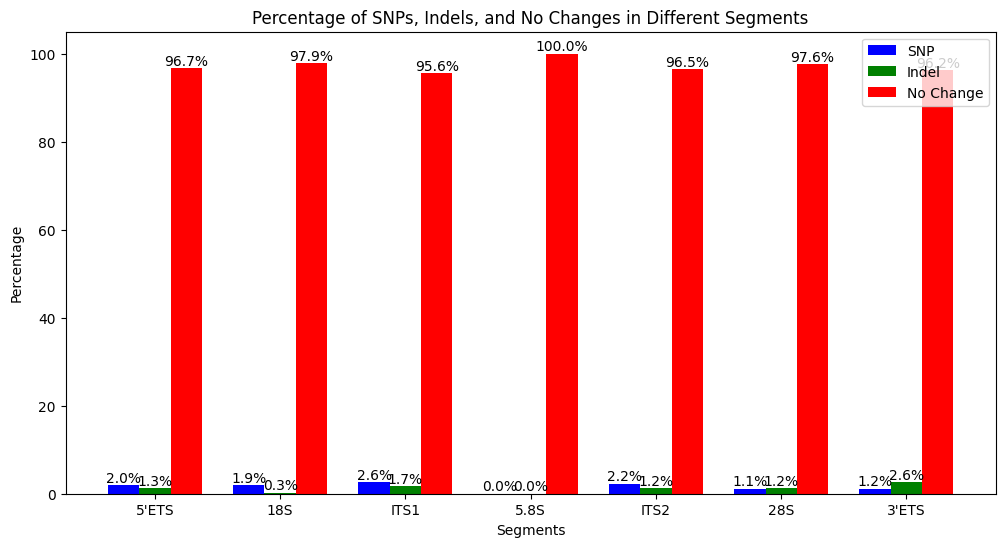

Overall SNP Percentage: 1.67%
Overall Indel Percentage: 1.17%
Overall No Change Percentage: 97.39%


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Spring 2024/Research Fair/Hochwagen/Individual Data/ERR3240115/'

all_positions = [
    [1, 3656, "5'ETS"],
    [3657, 5527, '18S'],
    [5528, 6622, 'ITS1'],
    [6623, 6779, '5.8S'],
    [6780, 7934, 'ITS2'],
    [7935, 12969, '28S'],
    [12970, 13314, "3'ETS"]
]

# Initialize dictionaries to store counts of unique SNPs, indels, and no changes
position_data = {i: {'snp': set(), 'indel': set(), 'no_change': 0} for i in range(1, 13315)}

# Function to parse VCF files and classify SNPs and indels
def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    for _, row in vcf_df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        if len(ref) == len(alt):
            variation = f"{ref}_{alt}"
            position_data[pos]['snp'].add(variation)
        else:
            variation = f"{ref}_{alt}"
            position_data[pos]['indel'].add(variation)
    
    # Track positions with no changes
    all_positions_set = set(range(1, 13315))
    vcf_positions_set = set(vcf_df['POS'].tolist())
    no_change_positions = all_positions_set - vcf_positions_set
    for pos in no_change_positions:
        position_data[pos]['no_change'] += 1

# Process each VCF file in the directory
vcf_files = glob.glob(vcf_directory + '*.vcf')
for vcf_file in vcf_files:
    parse_vcf(vcf_file)

# Prepare data for each segment
segment_data = {label: {'snp': 0, 'indel': 0, 'no_change': 0} for _, _, label in all_positions}

# Count occurrences for each segment
for pos in range(1, 13315):
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_data[label]['snp'] += len(position_data[pos]['snp'])
            segment_data[label]['indel'] += len(position_data[pos]['indel'])
            segment_data[label]['no_change'] += position_data[pos]['no_change']

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['snp'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (segment_data[label]['snp'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
segments = list(segment_percentages.keys())
snp_percentages = [segment_percentages[seg]['snp'] for seg in segments]
indel_percentages = [segment_percentages[seg]['indel'] for seg in segments]
no_change_percentages = [segment_percentages[seg]['no_change'] for seg in segments]

# Plotting the histogram
bar_width = 0.25
x = range(len(segments))

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, snp_percentages, color='b', width=bar_width, label='SNP')
bars2 = plt.bar([p + bar_width for p in x], indel_percentages, color='g', width=bar_width, label='Indel')
bars3 = plt.bar([p + bar_width * 2 for p in x], no_change_percentages, color='r', width=bar_width, label='No Change')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of SNPs, Indels, and No Changes in Different Segments')
plt.xticks([p + bar_width for p in x], segments)

plt.legend()

# Adding percentage labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.1f}%', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()

# Calculate overall percentages across the entire dataset
total_snp = sum(len(position_data[pos]['snp']) for pos in range(1, 13315))
total_indel = sum(len(position_data[pos]['indel']) for pos in range(1, 13315))
total_no_change = sum(position_data[pos]['no_change'] for pos in range(1, 13315))
total_positions = 13314

overall_snp_percentage = (total_snp / total_positions) * 100
overall_indel_percentage = (total_indel / total_positions) * 100
overall_no_change_percentage = (total_no_change / total_positions) * 100

# Print overall percentages
print(f"Overall SNP Percentage: {overall_snp_percentage:.2f}%")
print(f"Overall Indel Percentage: {overall_indel_percentage:.2f}%")
print(f"Overall No Change Percentage: {overall_no_change_percentage:.2f}%")


In [11]:
position_data

{1: {'snp': set(), 'indel': set(), 'no_change': 1},
 2: {'snp': set(), 'indel': set(), 'no_change': 1},
 3: {'snp': set(), 'indel': set(), 'no_change': 1},
 4: {'snp': set(), 'indel': set(), 'no_change': 1},
 5: {'snp': set(), 'indel': set(), 'no_change': 1},
 6: {'snp': set(), 'indel': set(), 'no_change': 1},
 7: {'snp': set(), 'indel': set(), 'no_change': 1},
 8: {'snp': set(), 'indel': set(), 'no_change': 1},
 9: {'snp': set(), 'indel': set(), 'no_change': 1},
 10: {'snp': set(), 'indel': set(), 'no_change': 1},
 11: {'snp': set(), 'indel': set(), 'no_change': 1},
 12: {'snp': set(), 'indel': set(), 'no_change': 1},
 13: {'snp': set(), 'indel': set(), 'no_change': 1},
 14: {'snp': set(), 'indel': set(), 'no_change': 1},
 15: {'snp': set(), 'indel': set(), 'no_change': 1},
 16: {'snp': set(), 'indel': set(), 'no_change': 1},
 17: {'snp': set(), 'indel': set(), 'no_change': 1},
 18: {'snp': set(), 'indel': set(), 'no_change': 1},
 19: {'snp': set(), 'indel': set(), 'no_change': 1},
 2

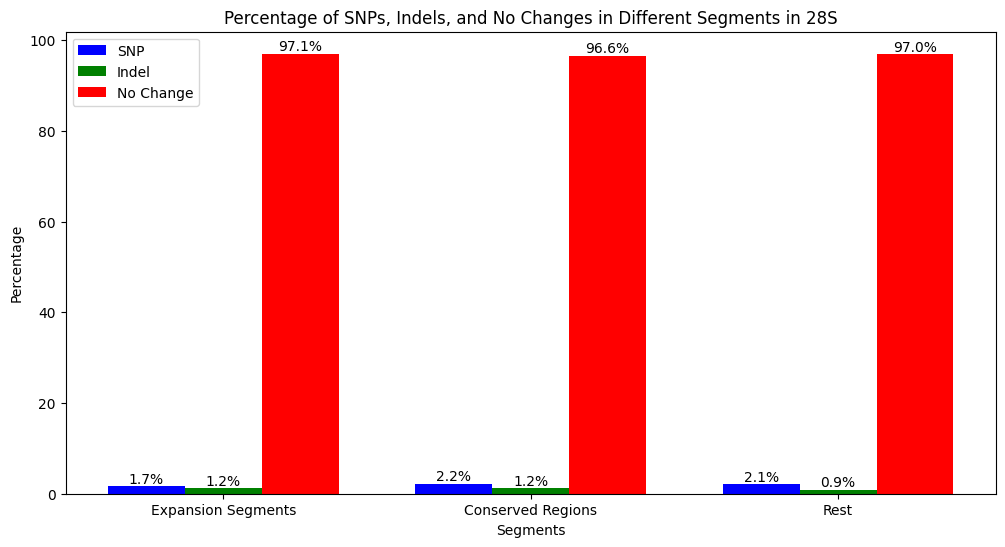

Overall SNP Percentage: 1.67%
Overall Indel Percentage: 1.17%
Overall No Change Percentage: 97.16%


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Define positions for different regions
expansion_positions1 = [[1, 500], [501, 1000]]  # Example positions
expansion_positions2 = [[2000, 2500], [2501, 3000]]  # Example positions
exp_cor = []
exp_cor.extend(expansion_positions1)
exp_cor.extend(expansion_positions2)

csvd_pos = [[1001, 1500], [1501, 2000]]  # Example positions
rRNA_positions = [[3001, 3500], [3501, 4000]]  # Example positions

# Initialize dictionaries to store counts of SNPs, indels, and no changes
position_data = {i: {'snp': set(), 'indel': set(), 'no_change': 0} for i in range(1, 13315)}

# Function to parse VCF files and classify SNPs and indels
def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    for _, row in vcf_df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        if len(ref) == len(alt):
            variation = f"{ref}_{alt}"
            position_data[pos]['snp'].add(variation)
        else:
            variation = f"{ref}_{alt}"
            position_data[pos]['indel'].add(variation)
    
    # Track positions with no changes
    all_positions_set = set(range(1, 13315))
    vcf_positions_set = set(vcf_df['POS'].tolist())
    no_change_positions = all_positions_set - vcf_positions_set
    for pos in no_change_positions:
        position_data[pos]['no_change'] += 1

# Process each VCF file in the directory
vcf_files = glob.glob(vcf_directory + '*.vcf')
for vcf_file in vcf_files:
    parse_vcf(vcf_file)

# Prepare data for each segment category
segment_data = {
    'Expansion Segments': {'snp': 0, 'indel': 0, 'no_change': 0},
    'Conserved Regions': {'snp': 0, 'indel': 0, 'no_change': 0},
    'Rest': {'snp': 0, 'indel': 0, 'no_change': 0}
}

# Count occurrences for each category
for pos in range(1, 13315):
    for start, end in exp_cor:
        if start <= pos <= end:
            segment_data['Expansion Segments']['snp'] += len(position_data[pos]['snp'])
            segment_data['Expansion Segments']['indel'] += len(position_data[pos]['indel'])
            segment_data['Expansion Segments']['no_change'] += position_data[pos]['no_change']
            break  # If position is found in this category, skip checking others
    
    for start, end in csvd_pos:
        if start <= pos <= end:
            segment_data['Conserved Regions']['snp'] += len(position_data[pos]['snp'])
            segment_data['Conserved Regions']['indel'] += len(position_data[pos]['indel'])
            segment_data['Conserved Regions']['no_change'] += position_data[pos]['no_change']
            break  # If position is found in this category, skip checking others
    
    for start, end in rRNA_positions:
        if start <= pos <= end:
            segment_data['Rest']['snp'] += len(position_data[pos]['snp'])
            segment_data['Rest']['indel'] += len(position_data[pos]['indel'])
            segment_data['Rest']['no_change'] += position_data[pos]['no_change']
            break  # If position is found in this category, skip checking others

# Calculate percentages for each category
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['snp'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (segment_data[label]['snp'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
categories = list(segment_percentages.keys())
snp_percentages = [segment_percentages[cat]['snp'] for cat in categories]
indel_percentages = [segment_percentages[cat]['indel'] for cat in categories]
no_change_percentages = [segment_percentages[cat]['no_change'] for cat in categories]

# Plotting the histogram
bar_width = 0.25
x = range(len(categories))

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, snp_percentages, color='b', width=bar_width, label='SNP')
bars2 = plt.bar([p + bar_width for p in x], indel_percentages, color='g', width=bar_width, label='Indel')
bars3 = plt.bar([p + bar_width * 2 for p in x], no_change_percentages, color='r', width=bar_width, label='No Change')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of SNPs, Indels, and No Changes in Different Segments in 28S')
plt.xticks([p + bar_width for p in x], categories)

plt.legend()

# Adding percentage labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.1f}%', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()

# Calculate overall percentages across the entire dataset
total_snp = sum(len(position_data[pos]['snp']) for pos in range(1, 13315))
total_indel = sum(len(position_data[pos]['indel']) for pos in range(1, 13315))
total_no_change = sum(position_data[pos]['no_change'] for pos in range(1, 13315))
total_positions = total_snp + total_indel + total_no_change  

overall_snp_percentage = (total_snp / total_positions) * 100
overall_indel_percentage = (total_indel / total_positions) * 100
overall_no_change_percentage = (total_no_change / total_positions) * 100

# Print overall percentages
print(f"Overall SNP Percentage: {overall_snp_percentage:.2f}%")
print(f"Overall Indel Percentage: {overall_indel_percentage:.2f}%")
print(f"Overall No Change Percentage: {overall_no_change_percentage:.2f}%")
